## Python üzerinde pandas ile veri manipülasyonu
Ödev talimatlarında herhangi bir analiz vb. beklentisi olmadığı için programlara aşinalığımızı test ettiğinizi varsayarak basit bir pandas ile veri manipülasyonu, lineer regresyon ve sonrasında da en temel python if conditional ve while loop ile oyun sunacağım.

In [2]:
#Pandas ile veri manipulasyonu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import LabelEncoder

#Veri içe aktarma
df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/diabetes.csv")

#İstenmeyen sütunları çıkarma
df = df.drop(columns=["Pregnancies", "SkinThickness", "Insulin", 'DiabetesPedigreeFunction'])

#İsim değiştirme
df = df.rename(columns={"BloodPressure": "Kan Basıncı", "Glucose": "Glikoz", "Age": "Yaş", "Outcome": "Sonuç"})

#Veri temizleme
print("Eksik değerler:\n", df.isnull().sum())

#Sonuç sütununu kategorik veri haline getirme
le = LabelEncoder()
df['Sonuç'] = le.fit_transform(df['Sonuç'])

#Veri eksik değerler yerine 0 vermiş, onlara medyan atama
for x in df.columns:
  df[x] = df[x].replace(0, df[x].median())

#Yapısını inceleme
df.describe()
print(f"Basıklık değerleri Yaş: {df['Yaş'].kurt()}, Glikoz: {df['Glikoz'].kurt()}, Kan Basıncı: {df['Kan Basıncı'].kurt()}, BMI: {df['BMI'].kurt()}")
print(f"Çarpıklık değerleri Yaş: {df['Yaş'].skew()}, Glikoz: {df['Glikoz'].skew()}, Kan Basıncı: {df['Kan Basıncı'].skew()}, BMI: {df['BMI'].skew()}")

#Aykırı değer kontrolü (IQR yöntemi)
for x in df.columns:
  Q1 = df[x].quantile(0.25)
  Q3 = df[x].quantile(0.75)
  IQR = Q3 - Q1
  outliers = df[(df[x] < Q1 - 1.5*IQR) | (df[x] > Q3 + 1.5*IQR)]
  print(f"Aykırı değer sayısı {x}:{outliers.shape[0]}")


Eksik değerler:
 Glikoz         0
Kan Basıncı    0
BMI            0
Yaş            0
Sonuç          0
dtype: int64
Basıklık değerleri Yaş: 0.6431588885398942, Glikoz: -0.2578474160780089, Kan Basıncı: 1.0982389536298531, BMI: 0.9212962224249819
Çarpıklık değerleri Yaş: 1.1295967011444805, Glikoz: 0.5355873034111183, Kan Basıncı: 0.1418850201030565, BMI: 0.6010587212883255
Aykırı değer sayısı Glikoz:0
Aykırı değer sayısı Kan Basıncı:14
Aykırı değer sayısı BMI:8
Aykırı değer sayısı Yaş:9
Aykırı değer sayısı Sonuç:0


## Histogramlar

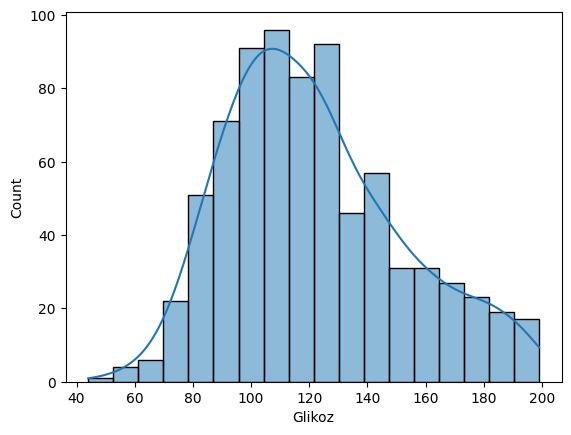

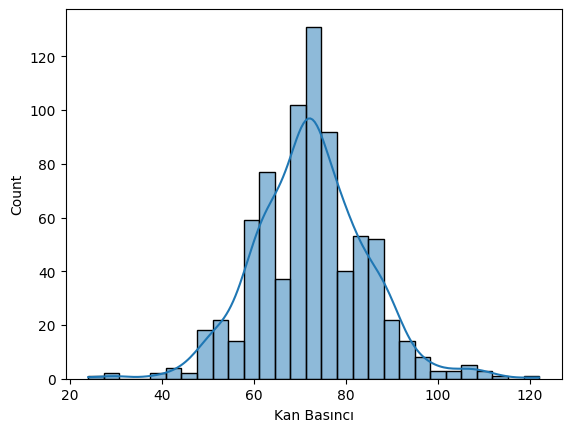

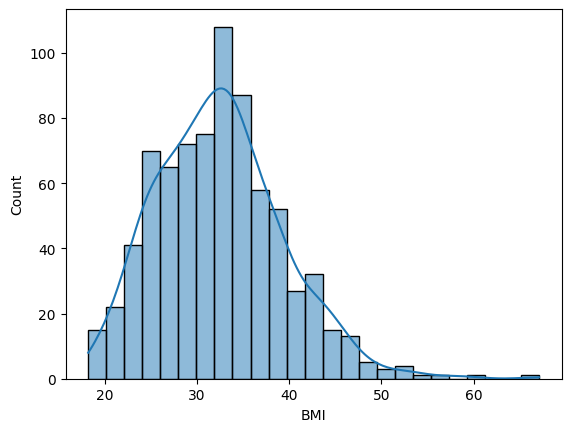

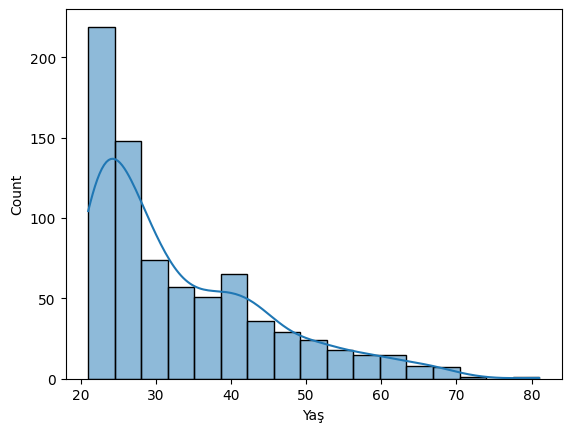

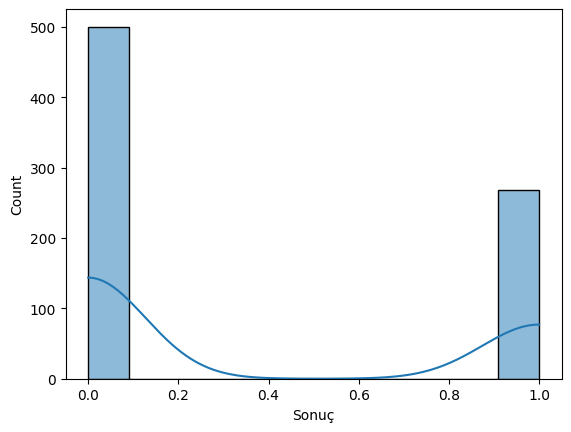

In [3]:
#Histogramları ile görselleştirme
for x in df.columns:
  sns.histplot(df[x], kde=True)
  plt.show()

## Korelasyon Matrisi

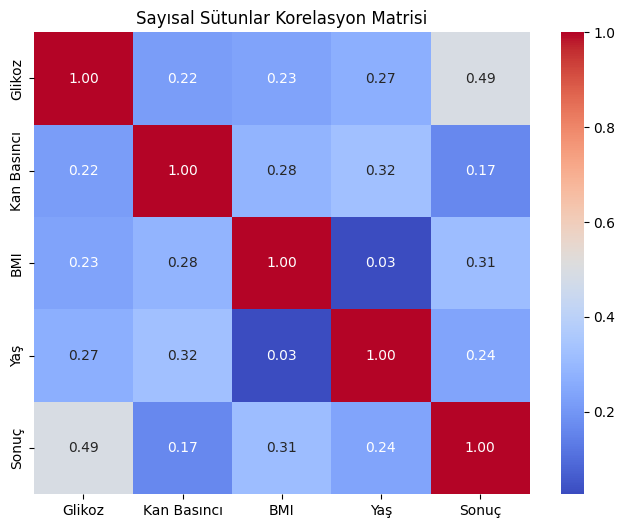

In [23]:
#Korelasyon matrisi
numeric_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sayısal Sütunlar Korelasyon Matrisi')
plt.show()

## Lineer Regresyon Modeli

In [21]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Bağımlı ve bağımsız değişkenleri tanımlama
X = df[['Kan Basıncı', 'Glikoz']]
Y = df['BMI']

#Veriyi eğitim ve test setlerine ayırma
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

#Lineer regresyon modelini oluşturma ve eğitme
model = LinearRegression()
model.fit(X_train, Y_train)

#Sonucun tahmini
Y_pred = model.predict(X_test)

#Model performansını değerlendirme
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Ortalama Mutlak Hata (MAE): {mae}")
print(f"R-kare (R2) Skoru: {r2}")

Ortalama Mutlak Hata (MAE): 4.8440150836519456
R-kare (R2) Skoru: 0.1687372100643657


## While loop ve if conditional bilgisi gösteren basit oyun

In [22]:
# Terminal üzerinden sayı tahmin etme oyunu
import random
y = random.randint(1,100)
x = int(input("1-100 arasında bir sayı tahmin edin:"))

while True:
  if x < y:
    print("Daha yukarı!")
    x = int(input("1-100 arasında bir sayı tahmin edin:"))
  elif x > y:
    print("Daha aşağı!")
    x = int(input("1-100 arasında bir sayı tahmin edin:"))
  else:
    print("Tebrikler!")
    break


KeyboardInterrupt: Interrupted by user